# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [1]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [2]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


2026-04-22 18:21:59.921481: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-22 18:21:59.992648: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-22 18:22:00.343732: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-22 18:22:00.343772: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-22 18:22:00.345295: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [3]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 4. Load the Data


In [4]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt
    # 2. Load y_train from train/y_train.txt
    # 3. Load X_test from test/X_test.txt
    # 4. Load y_test from test/y_test.txt
    # 5. Convert the labels to zero-based class indices by subtracting 1

    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"))
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt")).astype(int) - 1

    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt"))
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt")).astype(int) - 1

    return X_train, y_train, X_test, y_test
    raise NotImplementedError("Complete the data-loading function.")

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO: define num_features and num_classes
num_features = X_train.shape[1]
num_classes = len(np.unique(y_train))

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Number of input features:", num_features)
print("Number of classes:", num_classes)
 


X_train shape: (7352, 561)
X_test shape : (2947, 561)
Number of input features: 561
Number of classes: 6


## 5. Quick Inspection


In [5]:

label_counts = pd.Series(y_train).value_counts().sort_index()
summary_df = pd.DataFrame({
    "Class Index": range(num_classes),
    "Class Name": class_names,
    "Training Samples": label_counts.values
})
summary_df


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [6]:
# 1. BRING TOOLS TO CAVE FIRST!
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

def build_baseline_model(input_dim, num_classes):

    model = Sequential([
        # Door for data to enter
        Input(shape=(input_dim,)),
        
        # Brain parts with ReLU magic
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        
        # End of path. Softmax pick the tribe.
        Dense(num_classes, activation='softmax')
    ])
    
    # 2. Smart hunter Adam take small steps (1e-3 is 0.001)
    optimizer = Adam(learning_rate=1e-3)
    
    # 3. Tell model rules of hunt
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    #raise NotImplementedError("Complete the baseline DNN.")    
    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [7]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# Tell hunter to start practicing!
history = baseline_model.fit(
    x=X_train,              # The 7352 rows of data
    y=y_train,              # The correct tribe answers (labels)
    validation_split=0.2,   # Hide 20% for testing
    epochs=40,              # Practice for 40 days maximum
    batch_size=64,          # Look at 64 things at a time
    callbacks=callbacks     # Wise Shaman watches the practice
)


Epoch 1/40
92/92 [==============================] - 1s 8ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 1s 6ms/step - loss: 0.1640 - accuracy: 0.9367 - val_loss: 0.1402 - val_accuracy: 0.9381
Epoch 3/40
92/92 [==============================] - 1s 6ms/step - loss: 0.1165 - accuracy: 0.9561 - val_loss: 0.2180 - val_accuracy: 0.9259
Epoch 4/40
92/92 [==============================] - 1s 6ms/step - loss: 0.0886 - accuracy: 0.9641 - val_loss: 0.1500 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 1s 6ms/step - loss: 0.0885 - accuracy: 0.9645 - val_loss: 0.2037 - val_accuracy: 0.9218
Epoch 6/40
92/92 [==============================] - 1s 6ms/step - loss: 0.0748 - accuracy: 0.9711 - val_loss: 0.2056 - val_accuracy: 0.9313
Epoch 7/40
92/92 [==============================] - 1s 6ms/step - loss: 0.0765 - accuracy: 0.9716 - val_loss: 0.1482 - val_accuracy: 0.9443
Epoch 8/40
92/92 [==

### Training Curves


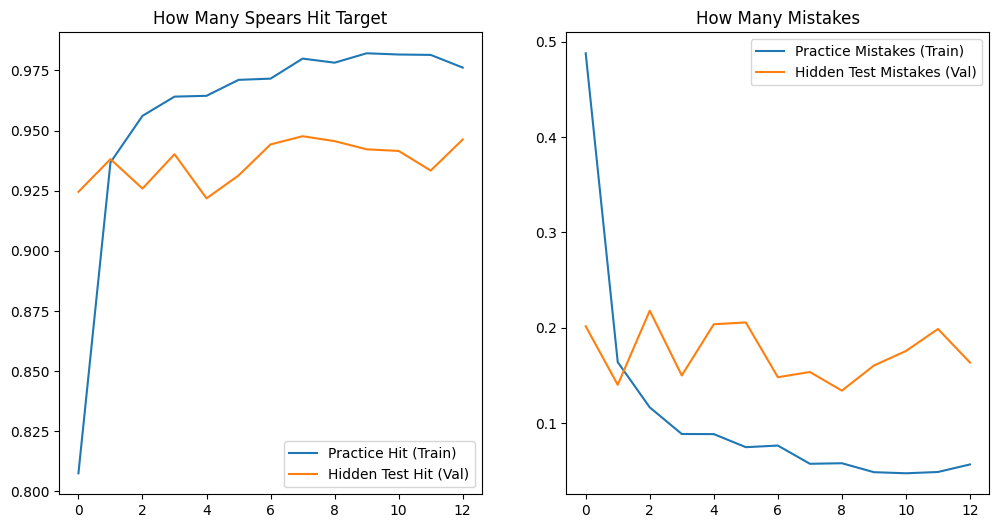

In [8]:
# Look inside the memory of the hunt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Count how many days hunter actually practiced
# (Maybe Shaman stopped him at day 12, maybe he went to 40)
epochs_range = range(len(acc))

# Make a big space on the wall for two paintings
plt.figure(figsize=(12, 6))

# --- FIRST PAINTING: SPEARS HIT (ACCURACY) ---
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st picture
plt.plot(epochs_range, acc, label='Practice Hit (Train)')
plt.plot(epochs_range, val_acc, label='Hidden Test Hit (Val)')
plt.legend(loc='lower right')
plt.title('How Many Spears Hit Target')

# --- SECOND PAINTING: MISTAKES (LOSS) ---
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd picture
plt.plot(epochs_range, loss, label='Practice Mistakes (Train)')
plt.plot(epochs_range, val_loss, label='Hidden Test Mistakes (Val)')
plt.legend(loc='upper right')
plt.title('How Many Mistakes')

# Show the wall to the tribe!
plt.show()


## 7. Evaluate the Baseline Keras Model


93/93 [==============================] - 0s 2ms/step
Hunter Score in New Forest: 0.9220

--- SHAMAN SCROLL (Classification Report) ---
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       496
           1       0.95      0.90      0.92       471
           2       0.89      0.95      0.92       420
           3       0.98      0.80      0.88       491
           4       0.81      0.98      0.89       532
           5       1.00      0.95      0.98       537

    accuracy                           0.92      2947
   macro avg       0.93      0.92      0.92      2947
weighted avg       0.93      0.92      0.92      2947


--- PAINTING GRID ON WALL (Confusion Matrix) ---


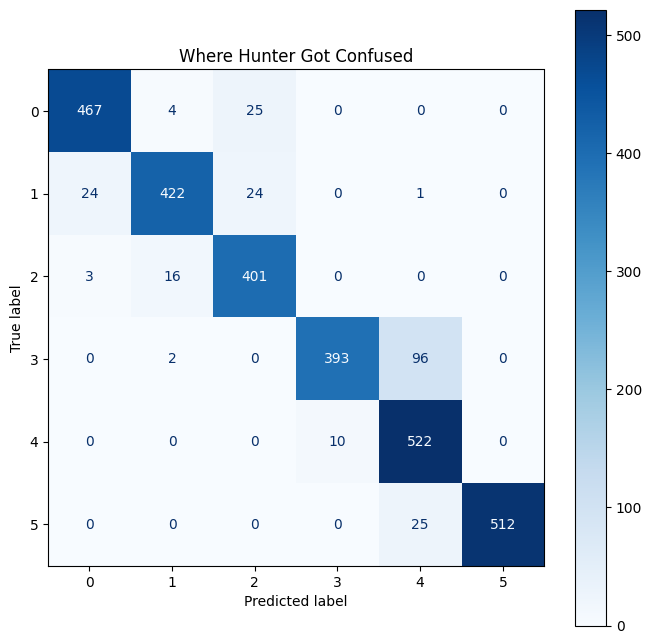

In [9]:
# 1. Throw spears at new forest! Get percents.
# y_pred_probs will look like: [0.1, 0.8, 0.05, 0.05, 0.0, 0.0]
y_pred_probs = baseline_model.predict(X_test)

# 2. Pick biggest percent for each animal (axis=1 means look across the row)
# y_pred will just be one number, like: 1 (for tribe 1)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Check simple score: how many hit right target?
test_acc = accuracy_score(y_test, y_pred)
print(f"Hunter Score in New Forest: {test_acc:.4f}")

# 4. Print the Shaman scroll
print("\n--- SHAMAN SCROLL (Classification Report) ---")
print(classification_report(y_test, y_pred))

# 5. Paint the confusion grid on the cave wall
print("\n--- PAINTING GRID ON WALL (Confusion Matrix) ---")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Make painting big so eyes can see
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap='Blues', ax=ax) # Use blueberry juice for paint
plt.title("Where Hunter Got Confused")
plt.show()


## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [10]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
# Show 300 practice animals
    for i in range(300):
        # Must yield a list with one item (the tensor)
        yield [X_train[i:i+1].astype(np.float32)]

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # SQUISH: Quantize the input only when the input dtype is int8 or uint8.
        if input_details['dtype'] == np.int8 or input_details['dtype'] == np.uint8:
            if input_scale != 0: # Avoid dividing by zero rock
                x = x / input_scale + input_zero_point
            x = x.astype(input_details['dtype'])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        if output_scale != 0: # If scale is not 0, it means it is quantized
            output = output.astype(np.float32)
            output = (output - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization and return the converted model.
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # Apply default optimization
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    # Set supported_types to [tf.float16]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # Apply default optimization
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    # Attach representative_dataset_gen
    converter.representative_dataset = representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    # Set inference_input_type and inference_output_type to tf.int8
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()


## 9. Post-Training Quantization (PTQ)


In [11]:
# --- 1. The Heavy Bag (FP32) ---
print("Magic Spell 1: Packing FP32...")
tflite_fp32 = convert_to_tflite_fp32(baseline_model)
size_fp32 = save_binary_model(tflite_fp32, "model_fp32.tflite")
acc_fp32, _ = evaluate_tflite_model(tflite_fp32, X_test, y_test)
print(f"FP32 Spear    -> Weight: {size_fp32:.2f} KB | Hits: {acc_fp32:.4f}\n")

# --- 2. The Squished Weight (Dynamic Range) ---
print("Magic Spell 2: Squishing Dynamic Range...")
tflite_dynamic = convert_to_tflite_dynamic_range(baseline_model)
size_dynamic = save_binary_model(tflite_dynamic, "model_dynamic.tflite")
acc_dynamic, _ = evaluate_tflite_model(tflite_dynamic, X_test, y_test)
print(f"Dynamic Spear -> Weight: {size_dynamic:.2f} KB | Hits: {acc_dynamic:.4f}\n")

# --- 3. The Half-Size (Float16) ---
print("Magic Spell 3: Chopping Float16...")
tflite_fp16 = convert_to_tflite_float16(baseline_model)
size_fp16 = save_binary_model(tflite_fp16, "model_fp16.tflite")
acc_fp16, _ = evaluate_tflite_model(tflite_fp16, X_test, y_test)
print(f"Float16 Spear -> Weight: {size_fp16:.2f} KB | Hits: {acc_fp16:.4f}\n")

# --- 4. The Ultimate Smash (Int8) ---
print("Magic Spell 4: Smashing to Int8 Tiny Rocks...")
tflite_int8 = convert_to_tflite_int8(baseline_model)
size_int8 = save_binary_model(tflite_int8, "model_int8.tflite")
acc_int8, _ = evaluate_tflite_model(tflite_int8, X_test, y_test)
print(f"Int8 Spear    -> Weight: {size_int8:.2f} KB | Hits: {acc_int8:.4f}\n")

# --- BIG SHAMAN SUMMARY ---
print("===========================================")
print("        SHAMAN TALE OF FOUR SPEARS")
print("===========================================")
# test_acc is from earlier when we judged big Keras model
print(f"Big Boulder (Keras Baseline) Hits: {test_acc:.4f}") 
print("-" * 43)
print(f"FP32    | Weight: {size_fp32:6.2f} KB | Hits: {acc_fp32:.4f}")
print(f"Dynamic | Weight: {size_dynamic:6.2f} KB | Hits: {acc_dynamic:.4f}")
print(f"Float16 | Weight: {size_fp16:6.2f} KB | Hits: {acc_fp16:.4f}")
print(f"Int8    | Weight: {size_int8:6.2f} KB | Hits: {acc_int8:.4f}")
print("===========================================")

Magic Spell 1: Packing FP32...
INFO:tensorflow:Assets written to: /tmp/tmpx17fgi77/assets


INFO:tensorflow:Assets written to: /tmp/tmpx17fgi77/assets
2026-04-22 18:22:16.854389: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 18:22:16.854460: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 18:22:16.854991: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpx17fgi77
2026-04-22 18:22:16.856029: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 18:22:16.856046: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpx17fgi77
2026-04-22 18:22:16.859089: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-22 18:22:16.859905: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 18:22:16.902173: I tensorflow/cc/saved_model/loader.cc:217] Running initializatio

FP32 Spear    -> Weight: 726.72 KB | Hits: 0.9220

Magic Spell 2: Squishing Dynamic Range...
INFO:tensorflow:Assets written to: /tmp/tmp30c871x6/assets


INFO:tensorflow:Assets written to: /tmp/tmp30c871x6/assets
2026-04-22 18:22:17.561715: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 18:22:17.561778: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 18:22:17.561946: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp30c871x6
2026-04-22 18:22:17.562804: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 18:22:17.562820: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp30c871x6
2026-04-22 18:22:17.566179: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 18:22:17.604951: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp30c871x6
2026-04-22 18:22:17.614621: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

Dynamic Spear -> Weight: 186.11 KB | Hits: 0.9213

Magic Spell 3: Chopping Float16...
INFO:tensorflow:Assets written to: /tmp/tmpkf7aavbi/assets


INFO:tensorflow:Assets written to: /tmp/tmpkf7aavbi/assets
2026-04-22 18:22:18.236797: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 18:22:18.236877: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 18:22:18.237039: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpkf7aavbi
2026-04-22 18:22:18.238659: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 18:22:18.238694: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpkf7aavbi
2026-04-22 18:22:18.242118: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 18:22:18.282828: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpkf7aavbi
2026-04-22 18:22:18.294204: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

Float16 Spear -> Weight: 365.71 KB | Hits: 0.9220

Magic Spell 4: Smashing to Int8 Tiny Rocks...
INFO:tensorflow:Assets written to: /tmp/tmp8ut0fbcs/assets


INFO:tensorflow:Assets written to: /tmp/tmp8ut0fbcs/assets


Int8 Spear    -> Weight: 185.34 KB | Hits: 0.9226

        SHAMAN TALE OF FOUR SPEARS
Big Boulder (Keras Baseline) Hits: 0.9220
-------------------------------------------
FP32    | Weight: 726.72 KB | Hits: 0.9220
Dynamic | Weight: 186.11 KB | Hits: 0.9213
Float16 | Weight: 365.71 KB | Hits: 0.9220
Int8    | Weight: 185.34 KB | Hits: 0.9226


/home/fang/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-22 18:22:19.090045: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 18:22:19.090101: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 18:22:19.090264: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp8ut0fbcs
2026-04-22 18:22:19.090979: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 18:22:19.090996: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp8ut0fbcs
2026-04-22 18:22:19.092956: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 18:22:19.127700: I tensorflow/cc/saved_model/loader.

## 10. PTQ Comparison: Accuracy and Model Size


In [12]:
# --- 1. BIG ROCK TABLE (DataFrame) ---
# Put all numbers in a neat pile
data = {
    "Model Family": ["Baseline", "Baseline", "Baseline", "Baseline"],
    "Format": ["TFLite FP32", "TFLite Dynamic", "TFLite Float16", "TFLite Int8"],
    "Test Accuracy": [acc_fp32, acc_dynamic, acc_fp16, acc_int8],
    "Model Size (KB)": [size_fp32, size_dynamic, size_fp16, size_int8]
}

# Turn pile into flat rock table
df_compare = pd.DataFrame(data)
print("--- CHIEF ROCK TABLE ---")
print(df_compare)

--- CHIEF ROCK TABLE ---
  Model Family          Format  Test Accuracy  Model Size (KB)
0     Baseline     TFLite FP32       0.921955       726.718750
1     Baseline  TFLite Dynamic       0.921276       186.109375
2     Baseline  TFLite Float16       0.921955       365.710938
3     Baseline     TFLite Int8       0.922633       185.335938


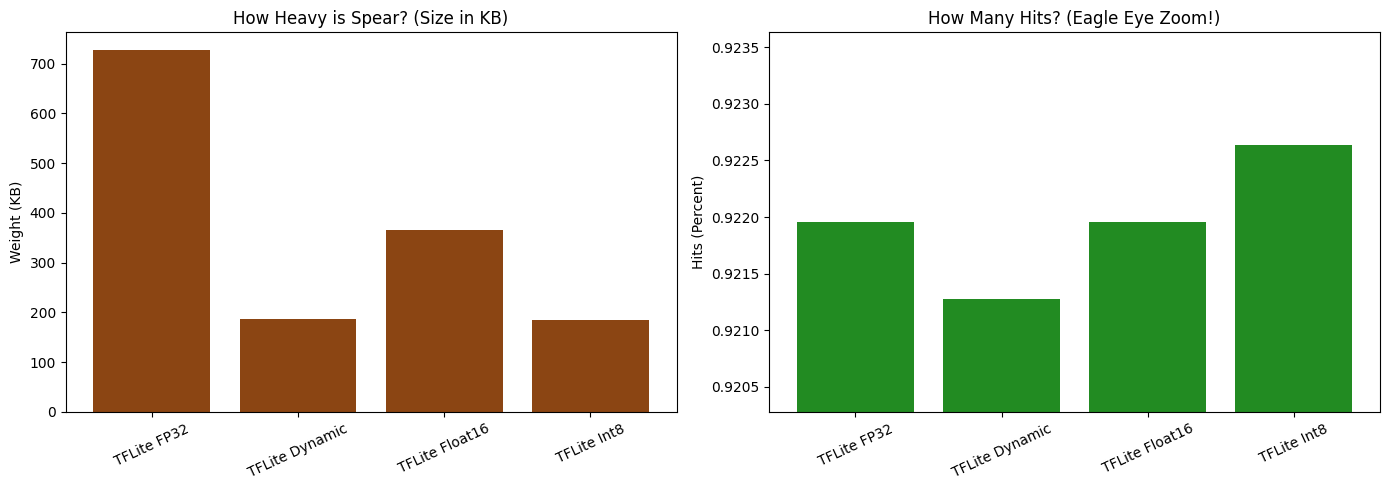

In [13]:
# --- 2. PAINT TALL STICKS - EAGLE EYE VIEW ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Painting 1: How heavy is spear? (Weight stays same)
axes[0].bar(df_compare["Format"], df_compare["Model Size (KB)"], color='saddlebrown')
axes[0].set_title("How Heavy is Spear? (Size in KB)")
axes[0].set_ylabel("Weight (KB)")
axes[0].tick_params(axis='x', rotation=25)

# Painting 2: How many hits? (ZOOM IN)
axes[1].bar(df_compare["Format"], df_compare["Test Accuracy"], color='forestgreen')
axes[1].set_title("How Many Hits? (Eagle Eye Zoom!)")
axes[1].set_ylabel("Hits (Percent)")

# --- MAGIC ZOOM TRICK ---
# Find the worst spear and best spear
lowest_hit = min(df_compare["Test Accuracy"])
highest_hit = max(df_compare["Test Accuracy"])

# Move ground just below worst spear, sky just above best spear!
axes[1].set_ylim([lowest_hit - 0.001, highest_hit + 0.001]) 
# ------------------------

axes[1].tick_params(axis='x', rotation=25)

# Show better wall to tribe!
plt.tight_layout()
plt.show()

### Confusion Matrix for the PTQ Int8 Model



--- SHAMAN SCROLL FOR TINY ROCK (Int8) ---
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       496
           1       0.95      0.89      0.92       471
           2       0.89      0.96      0.92       420
           3       0.98      0.80      0.88       491
           4       0.81      0.98      0.89       532
           5       1.00      0.95      0.98       537

    accuracy                           0.92      2947
   macro avg       0.93      0.92      0.92      2947
weighted avg       0.93      0.92      0.92      2947


--- PAINTING GRID FOR TINY ROCK (Confusion Matrix) ---


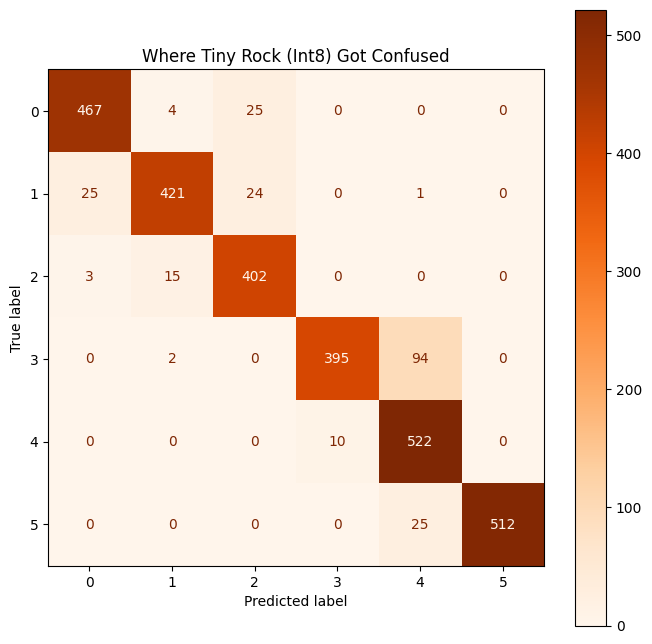

In [14]:
# --- 3. JUDGE TINY ROCK SPEAR (Int8 PTQ) ---
# We already threw Int8 spear at new forest earlier. 
# We need to get the exact predictions (y_pred_int8) from the evaluate function.
_, y_pred_int8 = evaluate_tflite_model(tflite_int8, X_test, y_test)

# Print Shaman Scroll
print("\n--- SHAMAN SCROLL FOR TINY ROCK (Int8) ---")
print(classification_report(y_test, y_pred_int8))

# Paint Grid for Tiny Rock
print("\n--- PAINTING GRID FOR TINY ROCK (Confusion Matrix) ---")
cm_int8 = confusion_matrix(y_test, y_pred_int8)
disp_int8 = ConfusionMatrixDisplay(confusion_matrix=cm_int8)

# Paint big grid with orange fire color
fig, ax = plt.subplots(figsize=(8, 8))
disp_int8.plot(cmap='Oranges', ax=ax)
plt.title("Where Tiny Rock (Int8) Got Confused")
plt.show()


## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [15]:
# --- Put QAT Spell on Hunter ---
qat_model = tfmot.quantization.keras.quantize_model(baseline_model)

# Give hunter new rules. 
# Learning rate is 1e-4 (0.0001). VERY small steps because he already knows 
# how to hunt, just needs to get used to the tiny spear.
qat_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


### Fine-Tune the QAT Model


In [16]:
# --- Practice for 8 Days (Fine-Tune) ---
print("Hunter practicing with fake tiny spear...")
qat_history = qat_model.fit(
    X_train, y_train,
    batch_size=64,
    epochs=8, # Only 8 days
    validation_split=0.2
)


Hunter practicing with fake tiny spear...
Epoch 1/8
92/92 [==============================] - 2s 9ms/step - loss: 0.0453 - accuracy: 0.9850 - val_loss: 0.1297 - val_accuracy: 0.9449
Epoch 2/8
92/92 [==============================] - 1s 7ms/step - loss: 0.0365 - accuracy: 0.9888 - val_loss: 0.1328 - val_accuracy: 0.9483
Epoch 3/8
92/92 [==============================] - 1s 8ms/step - loss: 0.0363 - accuracy: 0.9874 - val_loss: 0.1416 - val_accuracy: 0.9477
Epoch 4/8
92/92 [==============================] - 1s 7ms/step - loss: 0.0327 - accuracy: 0.9884 - val_loss: 0.1319 - val_accuracy: 0.9456
Epoch 5/8
92/92 [==============================] - 1s 7ms/step - loss: 0.0318 - accuracy: 0.9893 - val_loss: 0.1688 - val_accuracy: 0.9422
Epoch 6/8
92/92 [==============================] - 1s 7ms/step - loss: 0.0316 - accuracy: 0.9884 - val_loss: 0.1545 - val_accuracy: 0.9463
Epoch 7/8
92/92 [==============================] - 1s 7ms/step - loss: 0.0315 - accuracy: 0.9895 - val_loss: 0.1364 - val_ac

### Evaluate the QAT Keras Model


In [17]:
# --- Throw QAT Spears at New Forest ---
y_pred_probs_qat = qat_model.predict(X_test)
y_pred_qat = np.argmax(y_pred_probs_qat, axis=1)

# Count hits
qat_test_acc = accuracy_score(y_test, y_pred_qat)
print(f"\nQAT Hunter Score (Before Final Shrink): {qat_test_acc:.4f}")

# Read Shaman Scroll
print("\n--- SHAMAN SCROLL FOR QAT HUNTER ---")
print(classification_report(y_test, y_pred_qat))


93/93 [==============================] - 0s 3ms/step

QAT Hunter Score (Before Final Shrink): 0.9321

--- SHAMAN SCROLL FOR QAT HUNTER ---
              precision    recall  f1-score   support

           0       0.92      0.97      0.95       496
           1       0.94      0.90      0.92       471
           2       0.94      0.94      0.94       420
           3       0.97      0.85      0.91       491
           4       0.84      0.98      0.90       532
           5       1.00      0.95      0.98       537

    accuracy                           0.93      2947
   macro avg       0.94      0.93      0.93      2947
weighted avg       0.94      0.93      0.93      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [18]:
# --- Final Smash to Real Int8 Tiny spear ---
print("Smashing QAT model into real Int8...")
converter_qat = tf.lite.TFLiteConverter.from_keras_model(qat_model)

# Apply shrinking rules (same as before)
converter_qat.optimizations = [tf.lite.Optimize.DEFAULT]
converter_qat.representative_dataset = representative_dataset_gen
converter_qat.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_qat.inference_input_type = tf.int8
converter_qat.inference_output_type = tf.int8

# Make the final tiny spear
tflite_qat_int8 = converter_qat.convert()

# Save it in cave and weigh it
size_qat_int8 = save_binary_model(tflite_qat_int8, "model_qat_int8.tflite")

# Throw real tiny spear at new forest
acc_qat_int8, y_pred_qat_tflite = evaluate_tflite_model(tflite_qat_int8, X_test, y_test)

print("===========================================")
print("        SHAMAN TALE OF QAT SPEAR")
print("===========================================")
print(f"Old PTQ Int8 Hits  : {acc_int8:.4f}") # From earlier
print(f"New QAT Int8 Hits  : {acc_qat_int8:.4f}")
print(f"QAT Spear Weight   : {size_qat_int8:.2f} KB")
print("===========================================")


Smashing QAT model into real Int8...
INFO:tensorflow:Assets written to: /tmp/tmpne5_jjt3/assets


INFO:tensorflow:Assets written to: /tmp/tmpne5_jjt3/assets


        SHAMAN TALE OF QAT SPEAR
Old PTQ Int8 Hits  : 0.9226
New QAT Int8 Hits  : 0.9325
QAT Spear Weight   : 185.70 KB


/home/fang/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-22 18:22:29.006293: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 18:22:29.006338: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 18:22:29.006476: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpne5_jjt3
2026-04-22 18:22:29.008270: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 18:22:29.008287: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpne5_jjt3
2026-04-22 18:22:29.015641: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 18:22:29.076926: I tensorflow/cc/saved_model/loader.

## 12. PTQ Int8 vs QAT Int8


In [19]:
# --- FINAL CHIEF ROCK (DataFrame) ---
# Put the two tiny spears side-by-side
qat_data = {
    "Model": ["Old Spear (PTQ Int8)", "Ultimate Spear (QAT Int8)"],
    "Test Accuracy": [acc_int8, acc_qat_int8],
    "Model Size (KB)": [size_int8, size_qat_int8]
}

# Turn into flat rock
df_qat_compare = pd.DataFrame(qat_data)
print("--- FINAL CHIEF ROCK TABLE ---")
print(df_qat_compare)


--- FINAL CHIEF ROCK TABLE ---
                       Model  Test Accuracy  Model Size (KB)
0       Old Spear (PTQ Int8)       0.922633       185.335938
1  Ultimate Spear (QAT Int8)       0.932474       185.695312



--- PAINTING GRID FOR QAT TINY ROCK ---


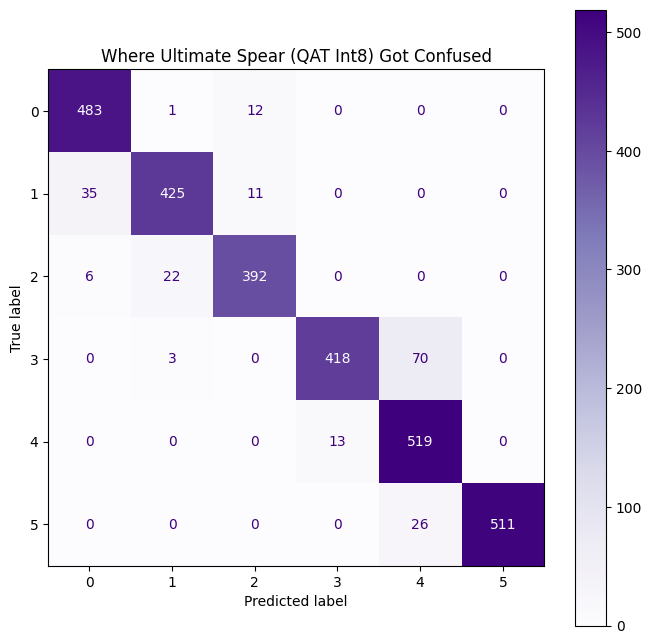

In [20]:
# --- PAINT GRID FOR ULTIMATE SPEAR (Confusion Matrix) ---
print("\n--- PAINTING GRID FOR QAT TINY ROCK ---")
# We use the predictions we got when we threw the QAT spear at the new forest
cm_qat = confusion_matrix(y_test, y_pred_qat_tflite)
disp_qat = ConfusionMatrixDisplay(confusion_matrix=cm_qat)

# Paint big grid. We use purple berry juice for Ultimate Spear!
fig, ax = plt.subplots(figsize=(8, 8))
disp_qat.plot(cmap='Purples', ax=ax) 
plt.title("Where Ultimate Spear (QAT Int8) Got Confused")
plt.show()


## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?
   TFLite Dynamic      @ 186.109375 KB
2. Which quantization method gave the best accuracy among the TensorFlow Lite models?
   TFLite Int8         @ 0.922633
3. Did QAT improve the final int8 model compared with PTQ int8?
   Yes by small margins. 
4. Why is this dataset a good fit for a DNN-based TinyML workflow?
   Because of this sets high dimentionality and few classes
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?
   Probably would do QAT Int8 because why not? you get some gains for just a small footprint increase


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
